# Introduction to AI: Machine Learning for Business - Final project

## Context

Congratulations, you’ve just been hired as an AI expert at a company.

For this final project you are required to choose and define a business problem to which you will apply machine learning.<br> 
Your final submission should include the following: 

- Problem definition
- Data Collection
- Data Processing
- Model Selection
- Results Visualization
- Results Interpretation

## Your dataset

The group should select a real life dataset.<br>
Finding an appropriate dataset is part of the game and will determine the quality of your work.<br>
**It requires spending a significant amount of time doing research.**

The selected dataset should contain at least 15 columns and at least 30000 rows.

## What should you do ?

Make a notebook telling interesting things about the data you have fetched, tell a story (or many) using everything you learned. Build predictive models and compare them.<br>
You have to submit at least a notebook and any resources you used (like images or any other files).

## Assessment 
Here are the criteria we will use to assess your work:

#### Is it meaningful?
As a machine learning expert you have to produce something meaningful enough, just plotting random data is not going to work.<br>
Like a story your analysis should have some kind of logical progression.

#### How well did you use the technical knowledge you’ve been taught?
Obviously, the way you use everything you learned during the lectures is going to be assessed.

#### Cleanliness, aesthetics and clarity of your notebook
Is your analysis full of unused code? Is it difficult to read? Have you tried to make it easy and enjoyable to read?

#### Innovation
Creativity, surprising things or any good initiatives you take are potential bonus points.

#### Accountability & Presentation
You will present your group work in a final presentation
- You will be assessed as a group, based on your notebook and your ppt (or equivalent) presentation
- You will be assessed individually on your oral presentation
- It must be stated in your document, who did what

### `Careful:`
**`This work is unique to each group, plagiarism is going to be measured by both machines and humans. Too many similarities between your work and any online or python buddy work will result in grade penalties.`**


**Good Luck!**


<h1 style="color: #fdc200ff;">Import Data</h1>

In [1]:
import pandas as pd
import os
from pathlib import Path

In [2]:
os.getcwd()

'c:\\Users\\DELL\\Desktop\\Cycle1\\Machine Learning\\Final Project\\Final_Project\\notebook'

In [3]:
file_path = Path("../")
data_path = os.path.join(file_path, "data", "Dataset.csv")
df = pd.read_csv(data_path, encoding="latin1")

In [4]:
# transform the date type
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"], format="%m/%d/%Y %H:%M", errors="coerce")
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"], format="%m/%d/%Y %H:%M", errors="coerce" )

<h1 style="color: #fdc200ff;">Data Information</h1>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country               180519 non-null  object        
 11  

In [6]:
print(df.shape)
print(list(df.columns))

(180519, 53)
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping d

In [7]:
df.describe(exclude=["object", "datetime"]).T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [8]:
df.describe(include="object").T

,count,unique,top,freq
Type,180519,4,DEBIT,69295
Delivery Status,180519,4,Late delivery,98977
Category Name,180519,50,Cleats,24551
Customer City,180519,563,Caguas,66770
Customer Country,180519,2,EE. UU.,111146
Customer Email,180519,1,XXXXXXXXX,180519
Customer Fname,180519,782,Mary,65150
Customer Lname,180511,1109,Smith,64104
Customer Password,180519,1,XXXXXXXXX,180519
Customer Segment,180519,3,Consumer,93504


In [9]:
df.describe(include="datetime").T

,count,mean,min,25%,50%,75%,max
order date (DateOrders),180519,2016-06-12 17:47:04.669868544,2015-01-01 00:00:00,2015-09-21 13:49:00,2016-06-11 13:06:00,2017-03-01 08:42:00,2018-01-31 23:38:00
shipping date (DateOrders),180519,2016-06-16 05:45:23.202433024,2015-01-03 00:00:00,2015-09-25 06:59:00,2016-06-15 08:32:00,2017-03-04 21:29:00,2018-02-06 22:14:00


In [10]:
# access missing values
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


<h1 style="color: #fdc200ff;">Problem Definition</h1>

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df["Days for shipping (real)"].value_counts()

Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

In [13]:
df["Delivery Status"].value_counts(normalize=True)

Delivery Status
Late delivery        0.548291
Advance shipping     0.230402
Shipping on time     0.178352
Shipping canceled    0.042954
Name: proportion, dtype: float64

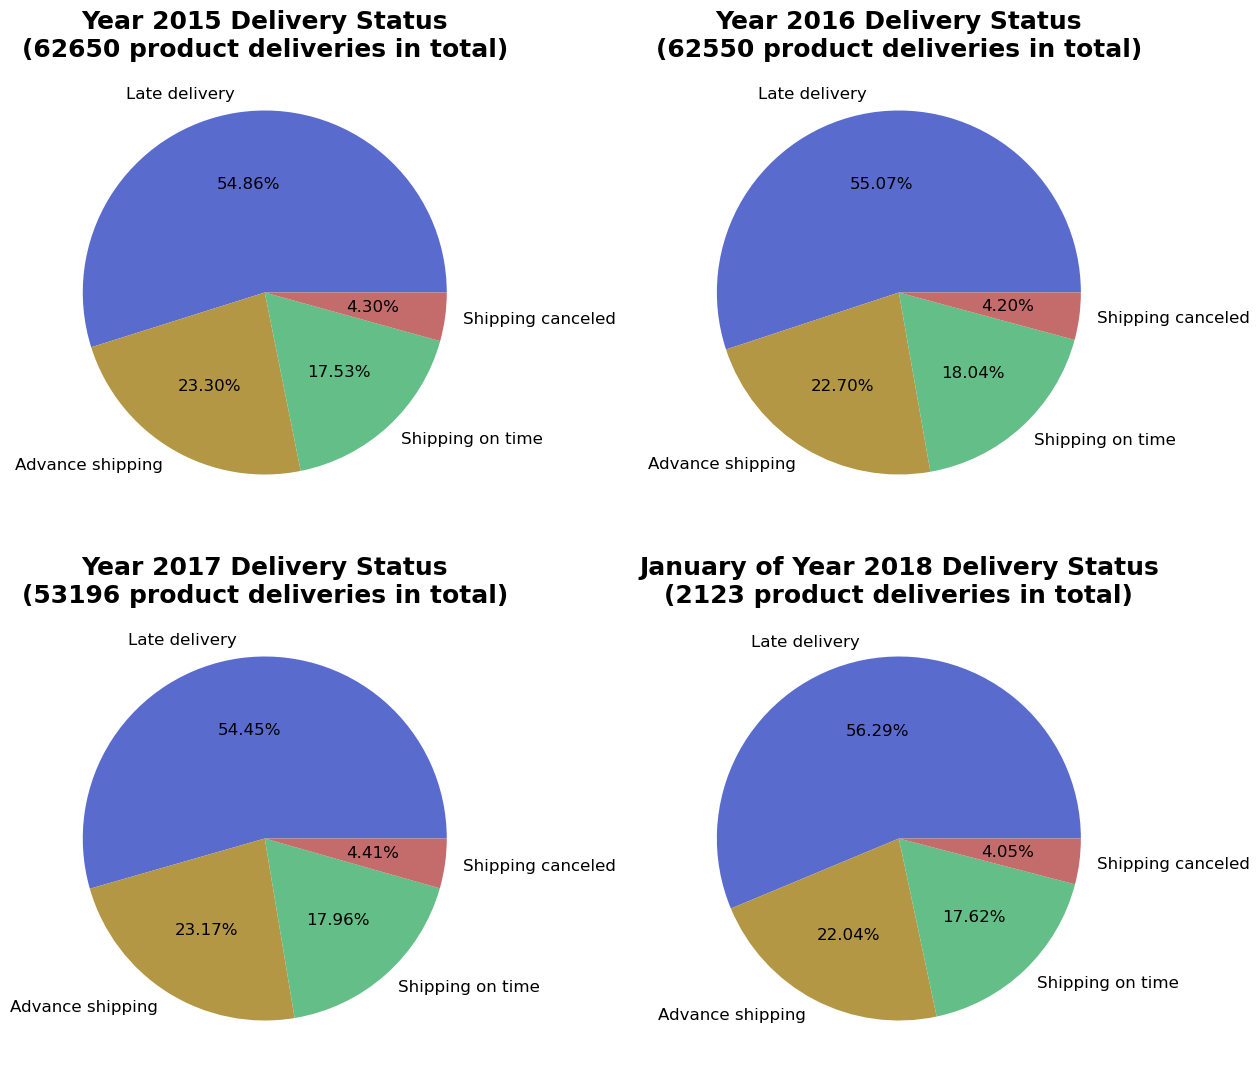

In [14]:
fig, axes_deliverStatus = plt.subplots(2, 2, figsize=(15, 13))
delivery_status_count_2015 = df.loc[df["order date (DateOrders)"].dt.year == 2015, "Delivery Status"].value_counts()
delivery_status_count_2016 = df.loc[df["order date (DateOrders)"].dt.year == 2016, "Delivery Status"].value_counts()
delivery_status_count_2017 = df.loc[df["order date (DateOrders)"].dt.year == 2017, "Delivery Status"].value_counts()
delivery_status_count_2018 = df.loc[df["order date (DateOrders)"].dt.year == 2018, "Delivery Status"].value_counts()
axes_deliverStatus[0, 0].pie(delivery_status_count_2015, labels=delivery_status_count_2015.index, autopct="%.2f%%", colors= ["#5A6BCE", "#B49745", "#64BE87", "#C46B6B"], textprops = {"fontsize": 12})
axes_deliverStatus[0, 1].pie(delivery_status_count_2016, labels=delivery_status_count_2016.index, autopct="%.2f%%", colors= ["#5A6BCE", "#B49745", "#64BE87", "#C46B6B"], textprops = {"fontsize": 12})
axes_deliverStatus[1, 0].pie(delivery_status_count_2017, labels=delivery_status_count_2017.index, autopct="%.2f%%", colors= ["#5A6BCE", "#B49745", "#64BE87", "#C46B6B"], textprops = {"fontsize": 12})
axes_deliverStatus[1, 1].pie(delivery_status_count_2018, labels=delivery_status_count_2018.index, autopct="%.2f%%", colors= ["#5A6BCE", "#B49745", "#64BE87", "#C46B6B"], textprops = {"fontsize": 12})
axes_deliverStatus[0, 0].set_title(f"Year 2015 Delivery Status\n({delivery_status_count_2015.sum()} product deliveries in total)", fontweight='bold', fontsize = 18)
axes_deliverStatus[0, 1].set_title(f"Year 2016 Delivery Status\n({delivery_status_count_2016.sum()} product deliveries in total)", fontweight='bold', fontsize = 18)
axes_deliverStatus[1, 0].set_title(f"Year 2017 Delivery Status\n({delivery_status_count_2017.sum()} product deliveries in total)", fontweight='bold', fontsize = 18)
axes_deliverStatus[1, 1].set_title(f"January of Year 2018 Delivery Status\n({delivery_status_count_2018.sum()} product deliveries in total)", fontweight='bold', fontsize = 18)
plt.show()


An analysis of the “Delivery Status” shows that the “Late Delivery” rate exceeded 50% throughout 2015, 2016, 2017, and January 2018. The rate remained very stable at around 55%.​

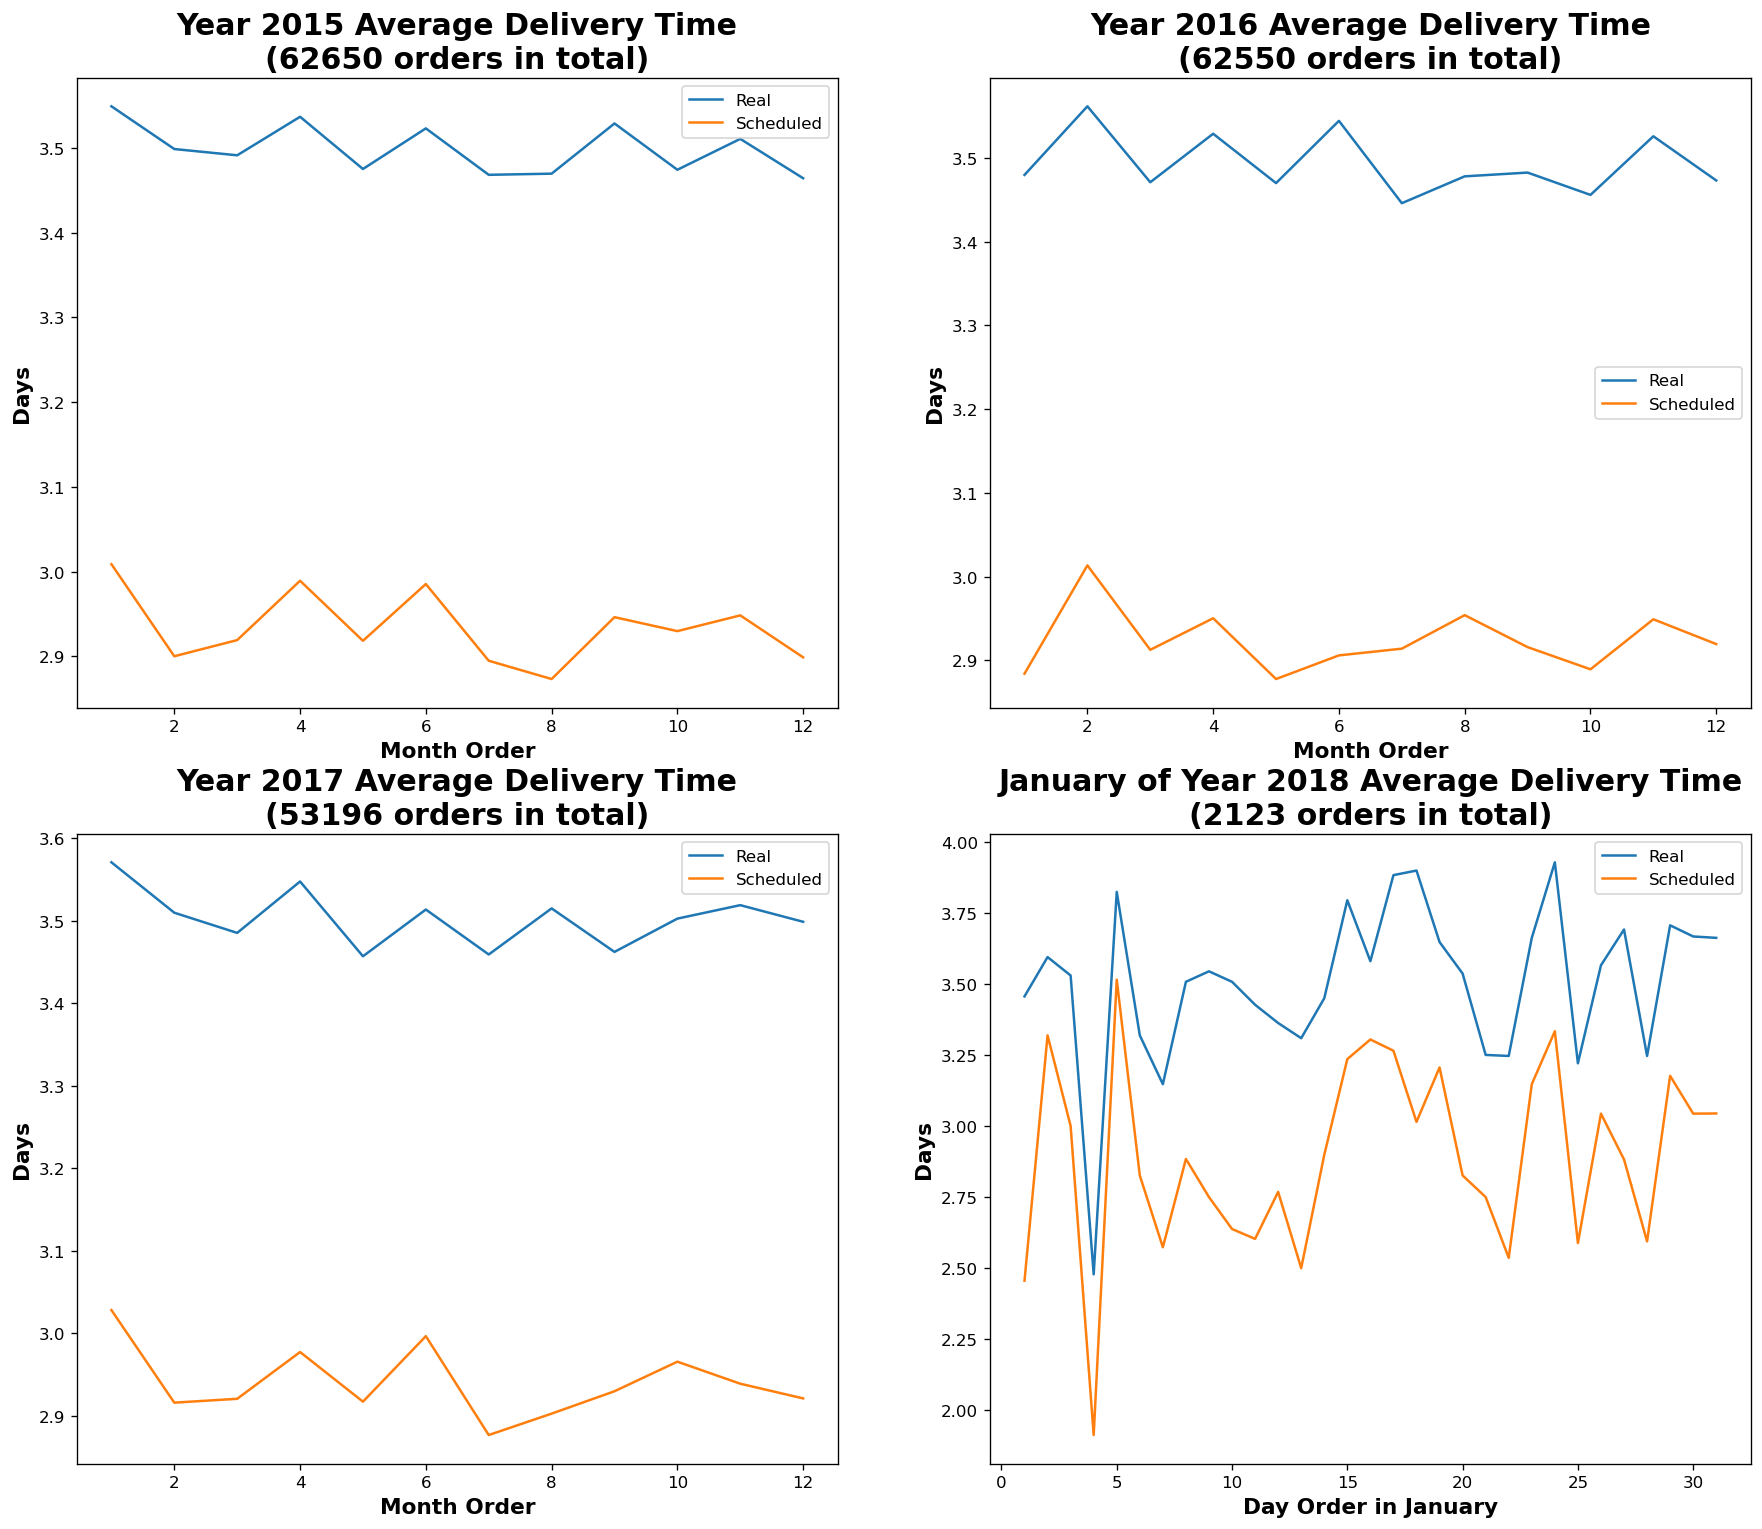

In [15]:
fig, axes_deliverTime = plt.subplots(2, 2, figsize=(18, 15), dpi = 120)
deliveryTime_real_2015 = df.loc[df["order date (DateOrders)"].dt.year == 2015, "Days for shipping (real)"].groupby(by=df["order date (DateOrders)"].dt.month).mean()
deliveryTime_real_2016 = df.loc[df["order date (DateOrders)"].dt.year == 2016, "Days for shipping (real)"].groupby(by=df["order date (DateOrders)"].dt.month).mean()
deliveryTime_real_2017 = df.loc[df["order date (DateOrders)"].dt.year == 2017, "Days for shipping (real)"].groupby(by=df["order date (DateOrders)"].dt.month).mean()
deliveryTime_real_2018 = df.loc[df["order date (DateOrders)"].dt.year == 2018, "Days for shipping (real)"].groupby(by=df["order date (DateOrders)"].dt.day).mean()
deliveryTime_sche_2015 = df.loc[df["order date (DateOrders)"].dt.year == 2015, "Days for shipment (scheduled)"].groupby(by=df["order date (DateOrders)"].dt.month).mean()
deliveryTime_sche_2016 = df.loc[df["order date (DateOrders)"].dt.year == 2016, "Days for shipment (scheduled)"].groupby(by=df["order date (DateOrders)"].dt.month).mean()
deliveryTime_sche_2017 = df.loc[df["order date (DateOrders)"].dt.year == 2017, "Days for shipment (scheduled)"].groupby(by=df["order date (DateOrders)"].dt.month).mean()
deliveryTime_sche_2018 = df.loc[df["order date (DateOrders)"].dt.year == 2018, "Days for shipment (scheduled)"].groupby(by=df["order date (DateOrders)"].dt.day).mean()
axes_deliverTime[0, 0].plot(deliveryTime_real_2015, label="Real")
axes_deliverTime[0, 0].plot(deliveryTime_sche_2015, label="Scheduled")
axes_deliverTime[0, 1].plot(deliveryTime_real_2016, label="Real")
axes_deliverTime[0, 1].plot(deliveryTime_sche_2016, label="Scheduled")
axes_deliverTime[1, 0].plot(deliveryTime_real_2017, label="Real")
axes_deliverTime[1, 0].plot(deliveryTime_sche_2017, label="Scheduled")
axes_deliverTime[1, 1].plot(deliveryTime_real_2018, label="Real")
axes_deliverTime[1, 1].plot(deliveryTime_sche_2018, label="Scheduled")
axes_deliverTime[0, 0].set_title(f"Year 2015 Average Delivery Time\n({delivery_status_count_2015.sum()} orders in total)", fontweight='bold', fontsize = 18)
axes_deliverTime[0, 1].set_title(f"Year 2016 Average Delivery Time\n({delivery_status_count_2016.sum()} orders in total)", fontweight='bold', fontsize = 18)
axes_deliverTime[1, 0].set_title(f"Year 2017 Average Delivery Time\n({delivery_status_count_2017.sum()} orders in total)", fontweight='bold', fontsize = 18)
axes_deliverTime[1, 1].set_title(f"January of Year 2018 Average Delivery Time\n({delivery_status_count_2018.sum()} orders in total)", fontweight='bold', fontsize = 18)
axes_deliverTime[0, 0].set_xlabel("Month Order", fontweight = "bold", fontsize = 13)
axes_deliverTime[0, 1].set_xlabel("Month Order", fontweight = "bold", fontsize = 13)
axes_deliverTime[1, 0].set_xlabel("Month Order", fontweight = "bold", fontsize = 13)
axes_deliverTime[1, 1].set_xlabel("Day Order in January", fontweight = "bold", fontsize = 13)
axes_deliverTime[0, 0].set_ylabel("Days", fontweight = "bold", fontsize = 13)
axes_deliverTime[0, 1].set_ylabel("Days", fontweight = "bold", fontsize = 13)
axes_deliverTime[1, 0].set_ylabel("Days", fontweight = "bold", fontsize = 13)
axes_deliverTime[1, 1].set_ylabel("Days", fontweight = "bold", fontsize = 13)
axes_deliverTime[0, 0].legend()
axes_deliverTime[0, 1].legend()
axes_deliverTime[1, 0].legend()
axes_deliverTime[1, 1].legend()
plt.show()

The graph, which compares the monthly average delivery time between Real Shipping Time and Scheduled Shipping Time, shows that the average Real Shipping Time consistently exceeds the Scheduled Shipping Time by approximately 0.5 to 1 day.

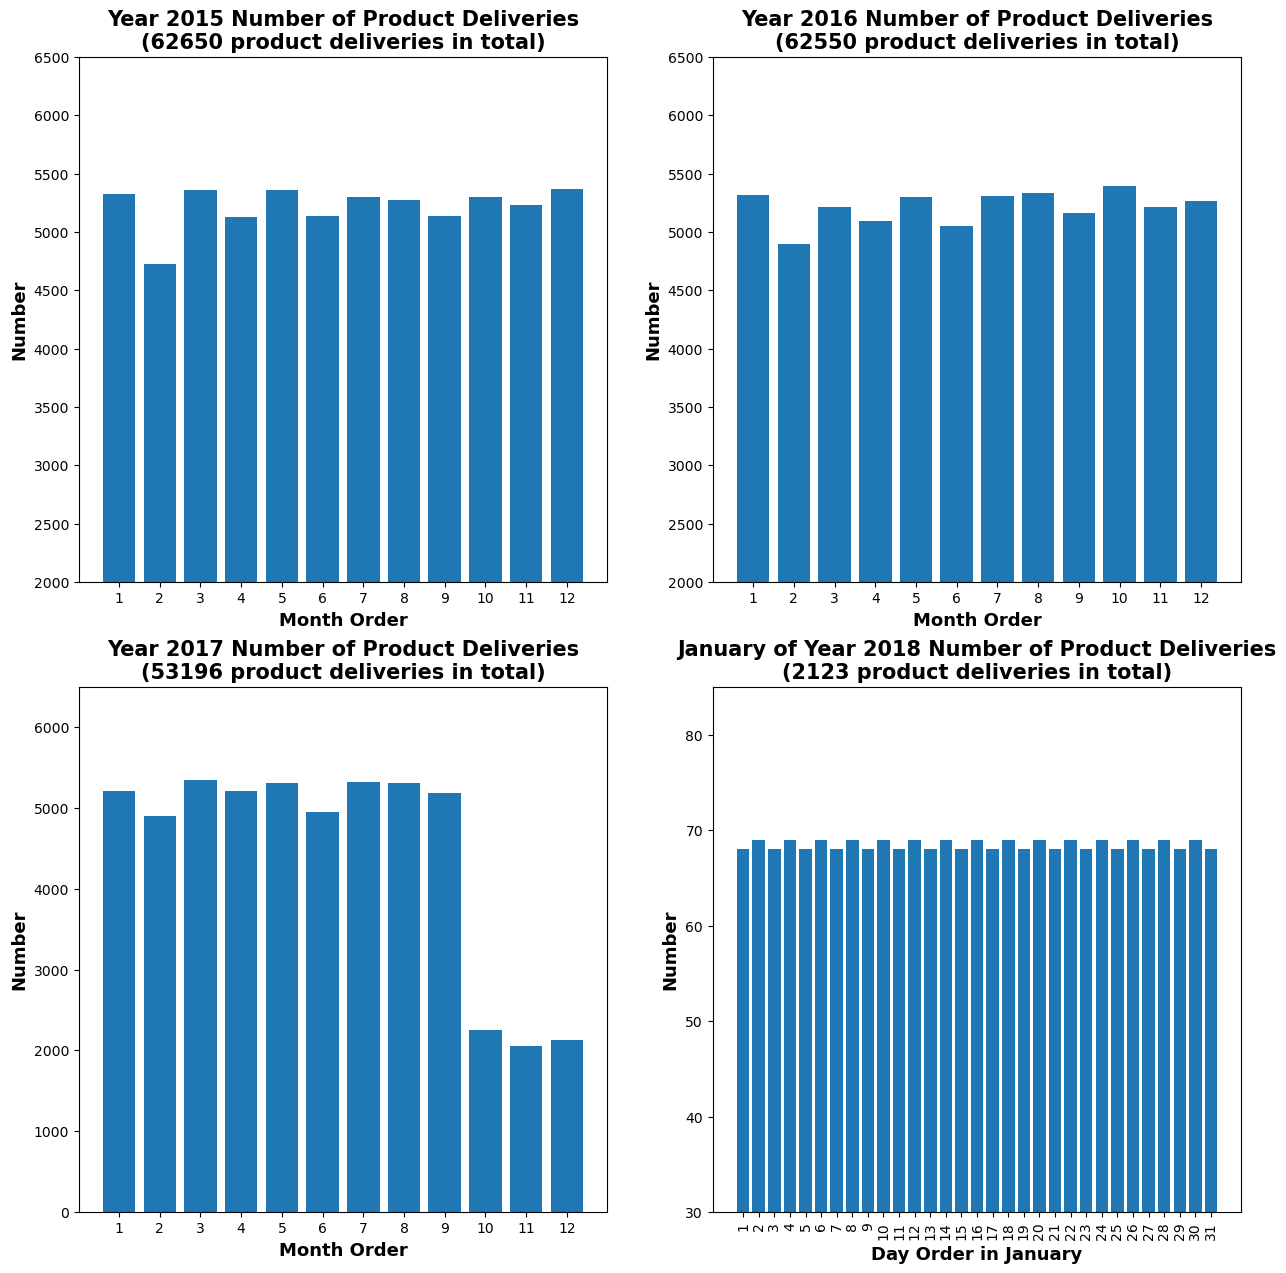

In [125]:
fig, axes_deliverCount = plt.subplots(2, 2, figsize=(15, 15))
deliverCount_2015 = df.loc[df["order date (DateOrders)"].dt.year == 2015, "Delivery Status"].groupby(by=df["order date (DateOrders)"].dt.month).size()
deliverCount_2016 = df.loc[df["order date (DateOrders)"].dt.year == 2016, "Delivery Status"].groupby(by=df["order date (DateOrders)"].dt.month).size()
deliverCount_2017 = df.loc[df["order date (DateOrders)"].dt.year == 2017, "Delivery Status"].groupby(by=df["order date (DateOrders)"].dt.month).size()
deliverCount_2018 = df.loc[df["order date (DateOrders)"].dt.year == 2018, "Delivery Status"].groupby(by=df["order date (DateOrders)"].dt.day).size()
axes_deliverCount[0, 0].bar(x=range(1,13), height=deliverCount_2015)
axes_deliverCount[0, 1].bar(x=range(1,13), height=deliverCount_2016)
axes_deliverCount[1, 0].bar(x=range(1,13), height=deliverCount_2017)
axes_deliverCount[1, 1].bar(x=range(1,32), height=deliverCount_2018)
axes_deliverCount[0, 0].set_title(f"Year 2015 Number of Product Deliveries\n({deliverCount_2015.sum()} product deliveries in total)", fontweight='bold', fontsize = 15)
axes_deliverCount[0, 1].set_title(f"Year 2016 Number of Product Deliveries\n({deliverCount_2016.sum()} product deliveries in total)", fontweight='bold', fontsize = 15)
axes_deliverCount[1, 0].set_title(f"Year 2017 Number of Product Deliveries\n({deliverCount_2017.sum()} product deliveries in total)", fontweight='bold', fontsize = 15)
axes_deliverCount[1, 1].set_title(f"January of Year 2018 Number of Product Deliveries\n({deliverCount_2018.sum()} product deliveries in total)", fontweight='bold', fontsize = 15)
axes_deliverCount[0, 0].set_xticks(ticks = range(1,13), labels = range(1,13))
axes_deliverCount[0, 1].set_xticks(ticks = range(1,13), labels = range(1,13))
axes_deliverCount[1, 0].set_xticks(ticks = range(1,13), labels = range(1,13))
axes_deliverCount[1, 1].set_xticks(ticks = range(1,32), labels = range(1,32), rotation = 90)
axes_deliverCount[0, 0].set_ylim(bottom = 2000, top = 6500)
axes_deliverCount[0, 1].set_ylim(bottom = 2000, top = 6500)
axes_deliverCount[1, 0].set_ylim(bottom = 0, top = 6500)
axes_deliverCount[1, 1].set_ylim(bottom = 30, top = 85)
axes_deliverCount[0, 0].set_xlabel("Month Order", fontweight = "bold", fontsize = 13)
axes_deliverCount[0, 1].set_xlabel("Month Order", fontweight = "bold", fontsize = 13)
axes_deliverCount[1, 0].set_xlabel("Month Order", fontweight = "bold", fontsize = 13)
axes_deliverCount[1, 1].set_xlabel("Day Order in January", fontweight = "bold", fontsize = 13)
axes_deliverCount[0, 0].set_ylabel("Number", fontweight = "bold", fontsize = 13)
axes_deliverCount[0, 1].set_ylabel("Number", fontweight = "bold", fontsize = 13)
axes_deliverCount[1, 0].set_ylabel("Number", fontweight = "bold", fontsize = 13)
axes_deliverCount[1, 1].set_ylabel("Number", fontweight = "bold", fontsize = 13)
plt.show()


An analysis of the number of product deliveries each year shows that deliveries were generally stable at around 5,000 per month, with little variation across months. Just there was a notable decrease at the end of 2015.

<p style="color: #fdc200ff; font-weight: bold">Problem Defined</p>
We can find that more than 50% of orders are "Late Delivery" in every year, and the average real deliver time for each month of every year is higher than scheduled.<br>
<br>
So the late deleviery rate is high for orders, which could lead to the low customer satisfaction, and then lose customer and get bad reviews. We need to compute the accurate real shipping days to give the reliable information to customter

<h1 style="color: #fdc200ff;">Feature Selection</h1>

<p>A check of correlation for Variables</p>

In [ ]:
from sklearn.preprocessing import OrdinalEncoder # more efficient for encoding multi columns

In [ ]:
le = OrdinalEncoder()
categorical_data = df.select_dtypes(include="object").drop(columns=["Delivery Status","Customer Email", "Customer Fname", "Customer Lname", "Customer Password", "Customer Street", "Product Image"])
categorical_data = pd.DataFrame(le.fit_transform(categorical_data), columns=categorical_data.columns)
# all fearures, ecluding id, target related features
df_labelEncoding = pd.concat([categorical_data, df.select_dtypes(exclude="object").drop(columns = ["Days for shipping (real)", "Days for shipment (scheduled)", "Late_delivery_risk", "Customer Id", "Customer Zipcode", "Order Customer Id", "Order Id", "Order Item Id", "Order Zipcode", "Product Description", "Product Status", "order date (DateOrders)", "shipping date (DateOrders)"] )], axis="columns")
df_labelEncoding.head(3)

,Type,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Market,Order City,Order Country,...,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Card Id,Product Category Id,Product Price
0,1.0,40.0,66.0,1.0,0.0,36.0,4.0,3.0,331.0,70.0,...,0.04,327.75,0.29,1,327.75,314.640015,91.250000,1360,73,327.75
1,3.0,40.0,66.0,1.0,0.0,36.0,4.0,3.0,391.0,69.0,...,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,1360,73,327.75
2,0.0,40.0,452.0,0.0,0.0,5.0,4.0,3.0,391.0,69.0,...,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,1360,73,327.75


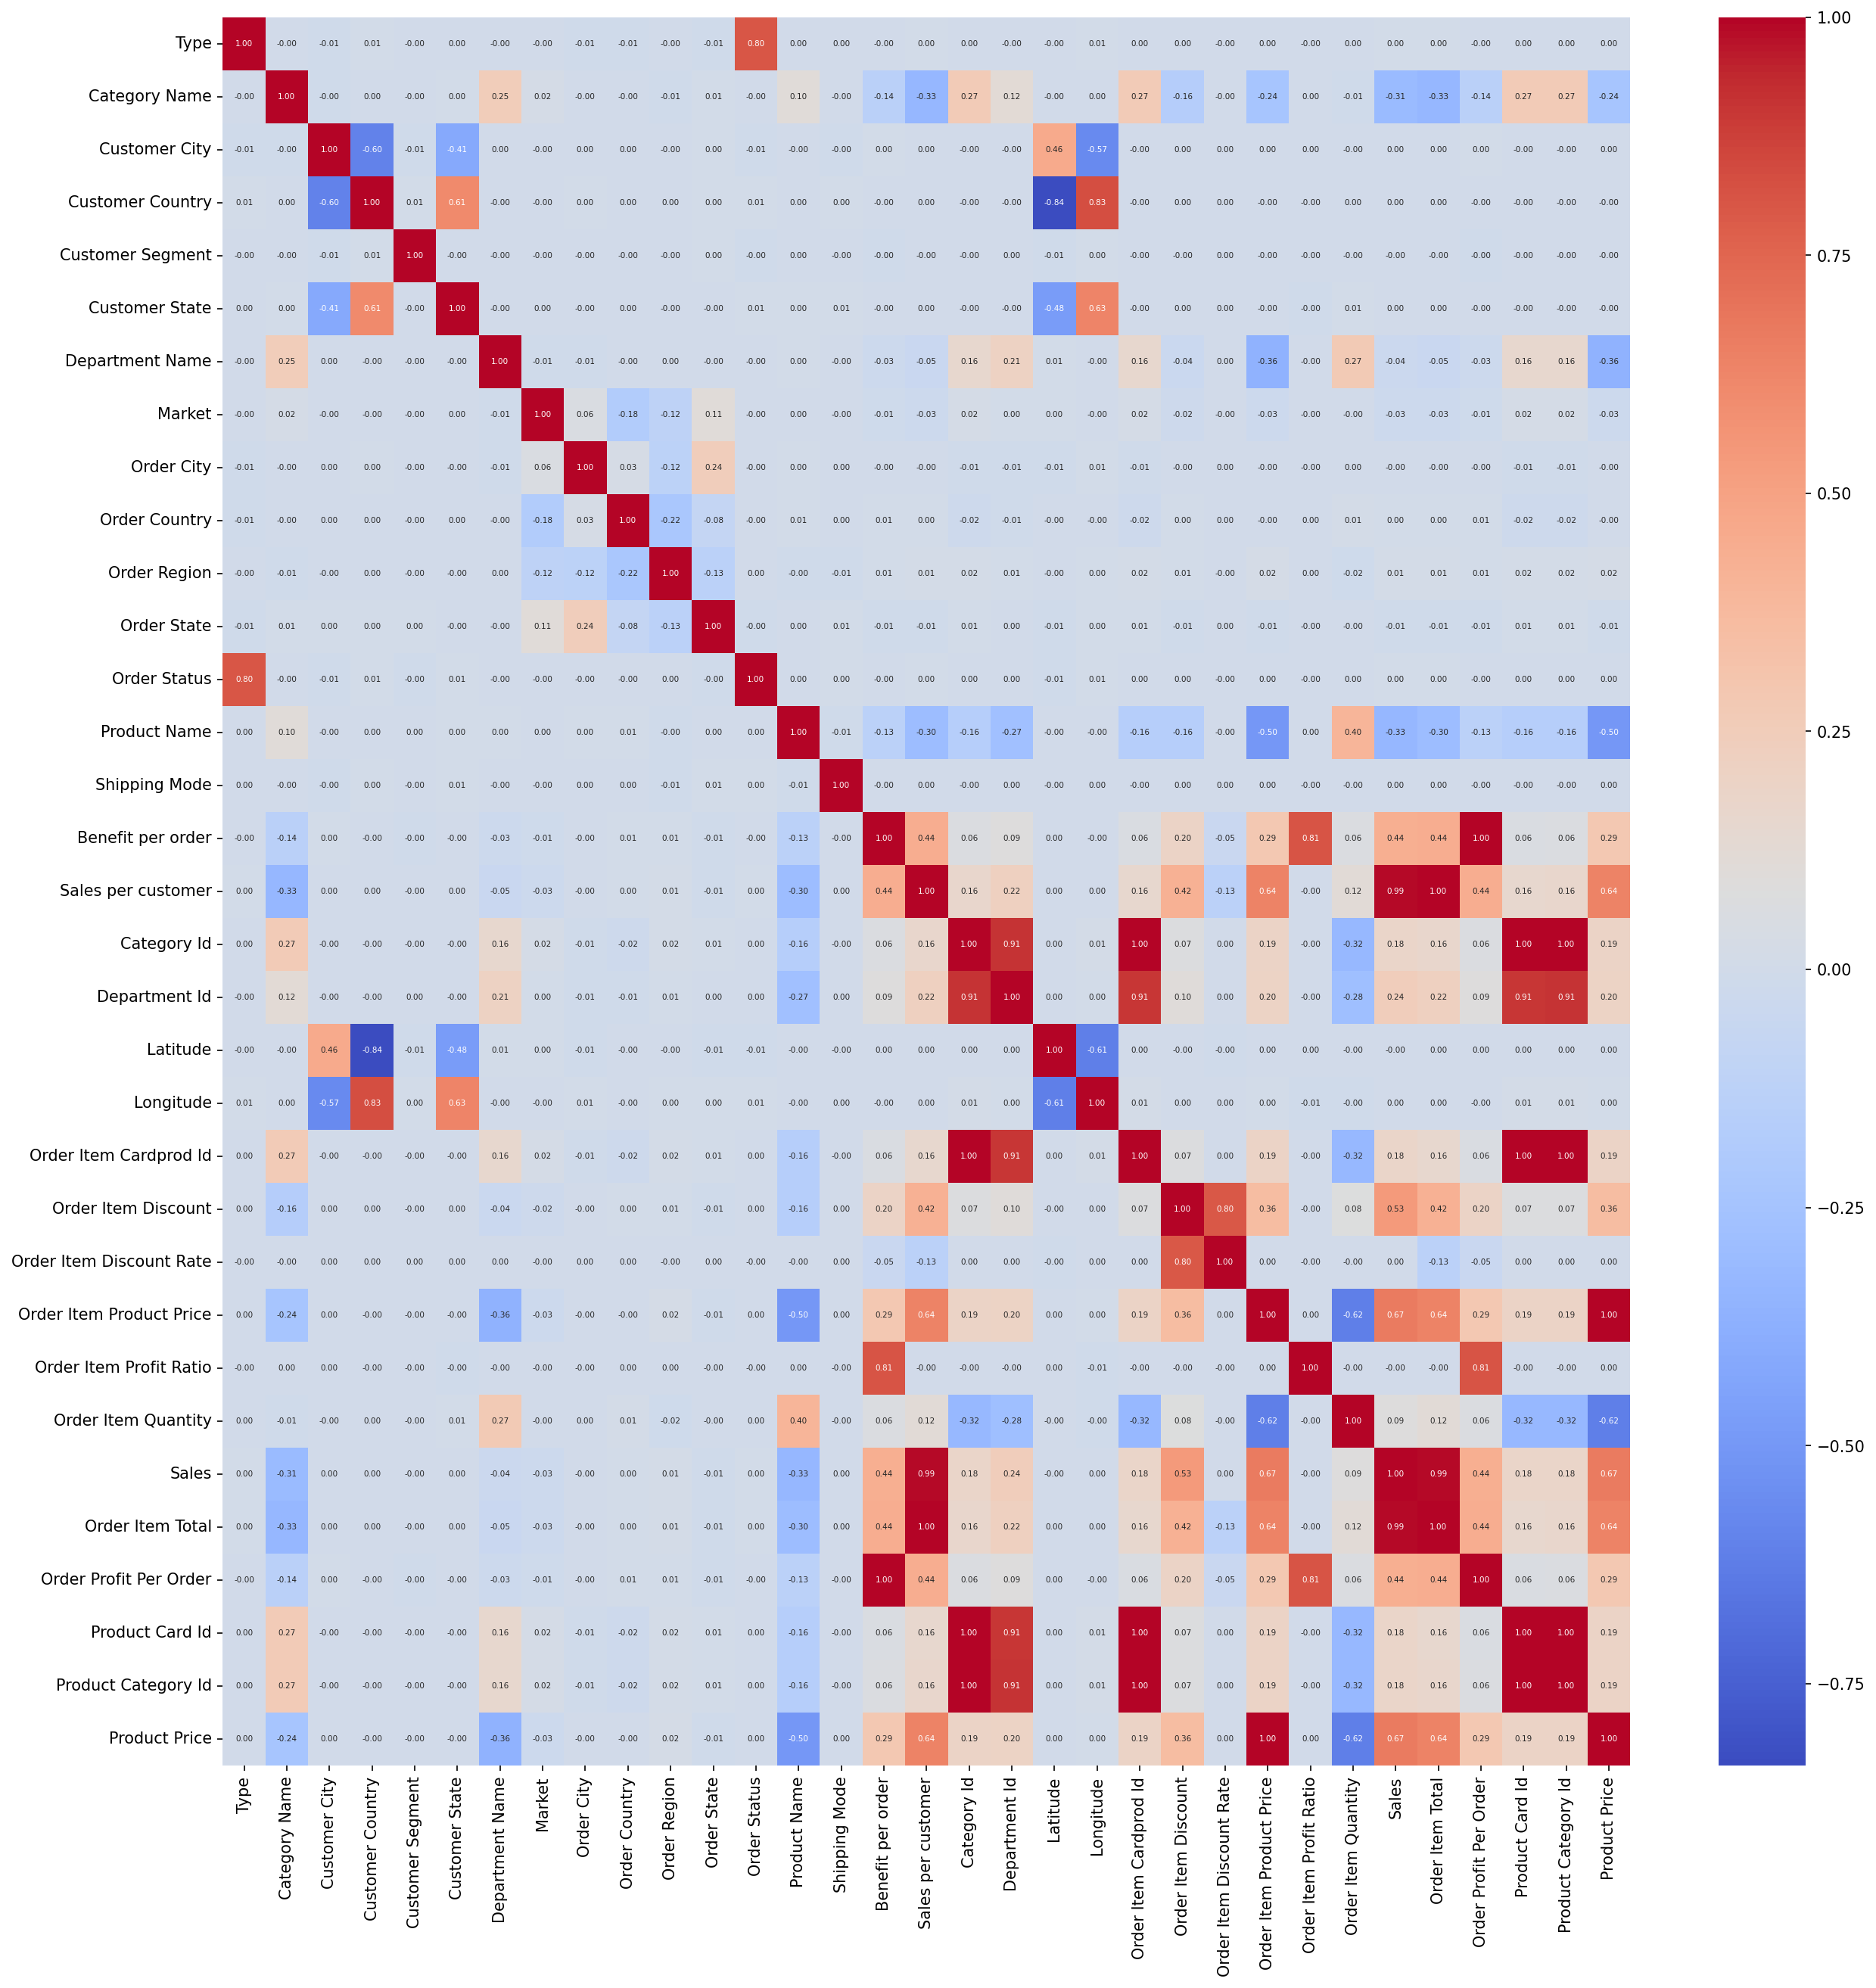

In [28]:
cor_variables = df_labelEncoding.corr(method = "spearman") # spearman correlation
plt.figure(figsize=(20, 20), dpi = 150)
sns.heatmap(cor_variables, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size":5})
plt.show()

In [30]:
# the pairs of high correlation(|r|>0.9)
fea_col = list(cor_variables.columns)
fea_id = list(cor_variables.index)
for col in fea_col:
    fea_id.remove(col)
    for id in fea_id:
        if abs(cor_variables.loc[id, col])>0.9:
            print(f"{col} & {id}")

Benefit per order & Order Profit Per Order
Sales per customer & Sales
Sales per customer & Order Item Total
Category Id & Department Id
Category Id & Order Item Cardprod Id
Category Id & Product Card Id
Category Id & Product Category Id
Department Id & Order Item Cardprod Id
Department Id & Product Card Id
Department Id & Product Category Id
Order Item Cardprod Id & Product Card Id
Order Item Cardprod Id & Product Category Id
Order Item Product Price & Product Price
Sales & Order Item Total
Product Card Id & Product Category Id


<p style="color: #fdc200ff; font-weight: bold">Feature Select</p>
From heatmap, we can see the pairs of high correlation (|r|>0.9) as above result, we remove one feature of each pair<br>

In [31]:
df_labelEncoding = df_labelEncoding.drop(columns=[ "Benefit per order", "Sales per customer", "Category Id", 
                                                  "Department Id", "Customer Country", "Order Item Cardprod Id", 
                                                  "Order Item Product Price", "Sales", "Product Card Id"])

In [32]:
# remove the columns with repeat value ration > 90% if there are
for col in df_labelEncoding.columns:
    if df_labelEncoding[col].value_counts(normalize=True).max() > 0.9:
        df_labelEncoding.drop(columns=col, inplace=True)


<h1 style="color: #fdc200ff;">Clustering</h1>

Cluster to capture hidden structure that might be missed

Elbow method to find the optimal K of clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
distorsions = []
X = df_labelEncoding[["Product Price", "Order Item Quantity", "Order Profit Per Order", "Order Item Total"]] # chosen four features
X = mms.fit_transform(X)
for k in range(1,16):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=42, tol=1e-04)
    km.fit_predict(X)
    distorsions.append(km.inertia_)

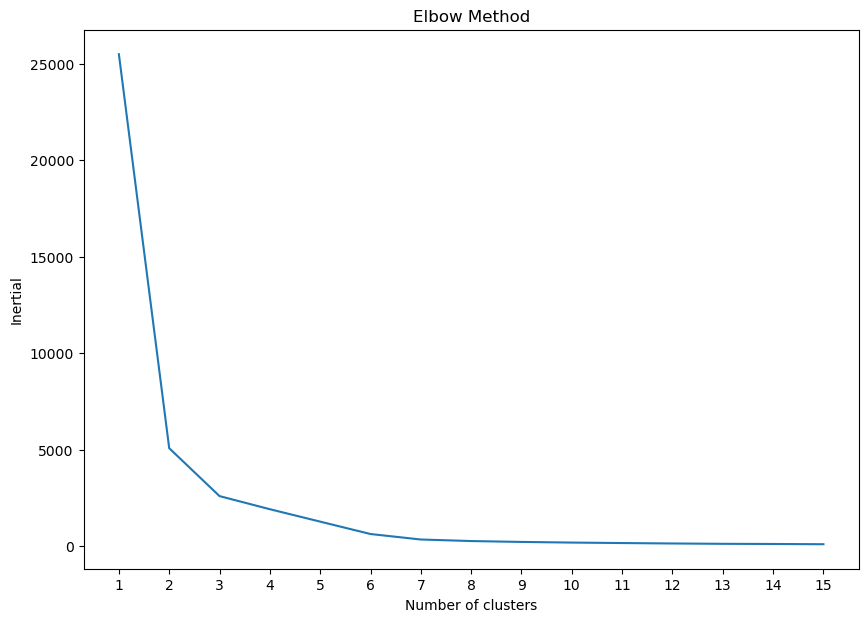

In [114]:
plt.figure(figsize=(10, 7))
plt.plot(range(1, 16), distorsions)
plt.xticks(range(1, 16))
plt.xlabel("Number of clusters")
plt.ylabel("Inertial")
plt.title("Elbow Method")
plt.show()

We can find that the optimal K is 3 for KMeans clustering

In [ ]:
km = KMeans(n_clusters=3, init="k-means++", n_init=10, max_iter=300, random_state=42, tol=1e-04)
XLabels = km.fit_predict(X)
XLabels = pd.DataFrame(data=XLabels, columns=["xLabels"])
df_labelEncoding = pd.concat([df_labelEncoding, XLabels], axis=1)

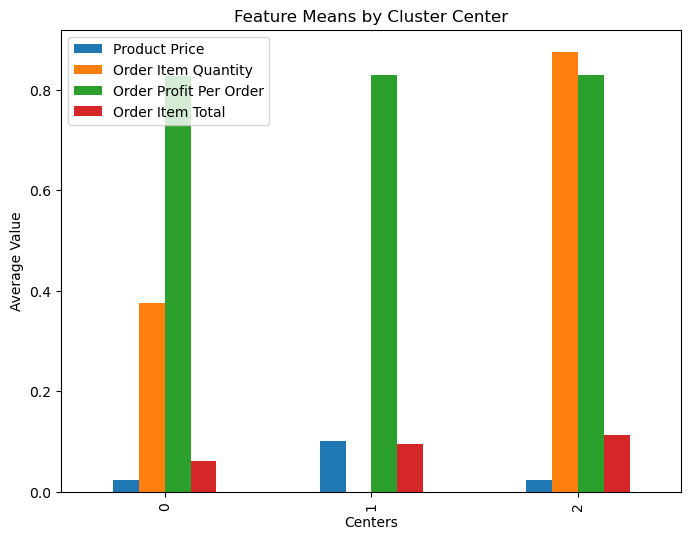

In [123]:
centers = km.cluster_centers_
center_df = pd.DataFrame(centers, columns=["Product Price", "Order Item Quantity", "Order Profit Per Order", "Order Item Total"])
center_df.plot(kind='bar', figsize=(8,6))
plt.title("Feature Means by Cluster Center")
plt.xlabel("Centers")
plt.ylabel("Average Value")
plt.show()

In [124]:
tag = df["Days for shipping (real)"] # target value
tag.value_counts()

Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Since the target value "Days for shipping (real)" is discrete [0, 1, 2, 3, 4, 5, 6] but ordinal. We choose to try both the Regression and Classification to check and compare the results. <br><br>
We will use the tree models for both the Regression and Classification, beacuse we used the LabelEncoding to deal with the categorical columns.

<h1 style="color: #fdc200ff;">1) Regression</h1>

In [34]:
# there are some categorical columns with values more than 15 types (ex. "Product Name", "Order City"). We use the Label Encoding to deal with them.
# So for this case, we only use tree-based model to do regresssion

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from lightgbm import LGBMRegressor
import numpy as np



In [35]:
# split the data into train set and test set
x_train_regress, x_test_regress, y_train_regress, y_test_regress = train_test_split(df_labelEncoding, tag, test_size=0.2, shuffle=True, random_state=42)

dtr = DecisionTreeRegressor(random_state=42)
rfg = RandomForestRegressor(n_estimators=10, random_state=42) # reduce n_estimators to save time for running, to get q quick result to check
gbr = GradientBoostingRegressor(n_estimators=10, random_state=42)
lgbmr = LGBMRegressor(n_estimators=10, random_state=42)

# parameter grid
model_paras = [[dtr, {"max_depth": range(2, 40), "min_samples_leaf": range(2, 20)}],
    [rfg, {"max_depth": range(2, 20), "min_samples_leaf": range(2, 20)}],
    [gbr, {"max_depth": range(2, 20), "min_samples_leaf": range(2, 20)}],
    [lgbmr, {"max_depth": range(2, 20), "min_child_samples": range(2, 20)}]]

In [36]:
# performance matrix
r2sc = []
r2_adj = []
rmse = []
nrmse = []

# function to oupt the performance matrix of different models using grid search
def evaluate_regression_model():
    temp = 0
    for model, paras in model_paras:
        grid_search_cv = GridSearchCV(estimator=model, param_grid=paras, cv=3, n_jobs=6, verbose=1)
        grid_search_cv.fit(x_train_regress, y_train_regress)
        best_paras = grid_search_cv.best_params_
        best_model = grid_search_cv.best_estimator_
        pred_train = best_model.predict(x_train_regress)
        pred_test = best_model.predict(x_test_regress)
        r2sc.append([model, r2_score(y_train_regress, pred_train), r2_score(y_test_regress, pred_test)])
        r2_adj.append([model, 1-(1-r2_score(y_train_regress, pred_train)) * (len(y_train_regress) -1) / (len(y_train_regress)- df_labelEncoding.shape[1] -1), 1-(1-r2_score(y_test_regress, pred_test)) * (len(y_test_regress) -1) / (len(y_test_regress)- df_labelEncoding.shape[1] -1)])
        rmse.append([model, root_mean_squared_error(y_train_regress, pred_train), root_mean_squared_error(y_test_regress, pred_test)])
        nrmse.append([model, root_mean_squared_error(y_train_regress, pred_train)/np.mean(y_train_regress), root_mean_squared_error(y_test_regress, pred_test)/np.mean(y_test_regress)])
        print(f"""
*************************************************************************
{model.__class__.__name__}:
Best parameters is {best_paras}
R2: training dataset: {r2sc[temp][1]: .3f} & test dataset: {r2sc[temp][2]: .3f}
Adjusted R2: training dataset: {r2_adj[temp][1]: .3f} & test dataset: {r2_adj[temp][2]: .3f}
RMSE: training dataset: {rmse[temp][1]: .3f} & test dataset: {rmse[temp][2]: .3f}
Normalized RMSE: training dataset: {nrmse[temp][1]: .3f} & test dataset: {nrmse[temp][2]: .3f}
*************************************************************************""")
        temp += 1


In [57]:
regress_evaluate = evaluate_regression_model()

Fitting 3 folds for each of 684 candidates, totalling 2052 fits

*************************************************************************
DecisionTreeRegressor:
Best parameters is {'max_depth': 9, 'min_samples_leaf': 3}
R2: training dataset:  0.400 & test dataset:  0.396
Adjusted R2: training dataset:  0.400 & test dataset:  0.396
RMSE: training dataset:  1.258 & test dataset:  1.262
Normalized RMSE: training dataset:  0.360 & test dataset:  0.361
*************************************************************************
Fitting 3 folds for each of 324 candidates, totalling 972 fits

*************************************************************************
RandomForestRegressor:
Best parameters is {'max_depth': 19, 'min_samples_leaf': 2}
R2: training dataset:  0.559 & test dataset:  0.473
Adjusted R2: training dataset:  0.559 & test dataset:  0.472
RMSE: training dataset:  1.078 & test dataset:  1.179
Normalized RMSE: training dataset:  0.308 & test dataset:  0.337
********************

Based on the results, Regression results are not good for all models, having the underfitting problem

<h1 style="color: #fdc200ff;">2) Classification</h1>

check target value imbalance

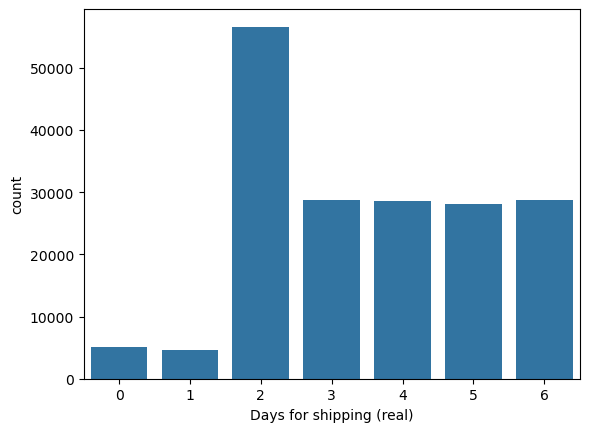

In [37]:
sns.countplot(data=df, x="Days for shipping (real)")
plt.show()

From the graph, we can find that there are less [0, 1] and more [2, 3, 4, 5, 6] in the target values, so we use "weighted" for caculation of classification performance metrix

In [38]:
# there are some categorical columns with values more than 15 types (ex. "Product Name", "Order City"). We use the Label Encoding to deal with them.
# So for this case, we only use tree-based model to do classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, auc

In [39]:
# split the data into train set and test set
x_train_cla, x_test_cla, y_train_cla, y_test_cla = train_test_split(df_labelEncoding, tag, test_size=0.2, shuffle=True, stratify=tag, random_state=42)

dtc = DecisionTreeClassifier(random_state=42)
rfc = RandomForestClassifier(n_estimators=10, random_state=42) # n_estimators=100 is too heavy to run
lgbmc = LGBMClassifier(n_estimators=10, random_state=42)

# parameter grid
model_paras_cla = [[dtc, {"max_depth": range(2, 40), "min_samples_leaf": range(2, 20)}],
    [rfc, {"max_depth": range(2, 20), "min_samples_leaf": range(2, 20)}],
    [lgbmc, {"max_depth": range(2, 20), "min_child_samples": range(2, 20)}]]

In [40]:
# performance matrix
acc_sc = []
pre_sc = []
rec_sc = []
f1_sc = []
auroc_sc = []

# function to oupt the performance matrix of different models using grid search
def evaluate_classifier_model():
    temp = 0
    for model, paras in model_paras_cla:
        grid_search_cv = GridSearchCV(estimator=model, param_grid=paras, cv=3, n_jobs=6, verbose=1)
        grid_search_cv.fit(x_train_cla, y_train_cla)
        best_paras = grid_search_cv.best_params_
        best_model = grid_search_cv.best_estimator_
        pred_test = best_model.predict(x_test_cla)
        pred_test_proba = best_model.predict_proba(x_test_cla)
        acc_sc.append([model, accuracy_score(y_test_cla, pred_test)])
        pre_sc.append([model,  precision_score(y_test_cla, pred_test, average='weighted')]) # "weighted" for imblanced problem
        rec_sc.append([model, recall_score(y_test_cla, pred_test, average='weighted')])
        f1_sc.append([model, f1_score(y_test_cla, pred_test, average='weighted')])
        auroc_sc.append([model, roc_auc_score(y_test_cla, pred_test_proba, average='micro', multi_class="ovr")]) # "micro" for imblanced problem
        cm  = confusion_matrix(y_test_cla, pred_test)
        print(f"""
*************************************************************************
{model.__class__.__name__}:
Best parameters is {best_paras}
Accuracy:{acc_sc[temp][1]: .3f}, Precision:{pre_sc[temp][1]: .3f}, Recall:{rec_sc[temp][1]: .3f}, F1_score:{f1_sc[temp][1]: .3f}
AUROC:{auroc_sc[temp][1]: .3f}
Confusion Matrix: 
{cm}
*************************************************************************""")
        temp += 1

In [62]:
classifier_evaluate = evaluate_classifier_model()

Fitting 3 folds for each of 684 candidates, totalling 2052 fits

*************************************************************************
DecisionTreeClassifier:
Best parameters is {'max_depth': 39, 'min_samples_leaf': 2}
Accuracy: 0.729, Precision: 0.727, Recall: 0.729, F1_score: 0.727
AUROC: 0.884
Confusion Matrix: 
[[ 873  143    0    0    0    0    0]
 [ 191  740    0    0    0    0    0]
 [   0    0 9622  389  416  409  488]
 [   0    0  634 3956  356  357  450]
 [   0    0  548  564 3835  335  421]
 [   0    0  585  526  475 3632  414]
 [   0    0  627  514  499  453 3652]]
*************************************************************************
Fitting 3 folds for each of 324 candidates, totalling 972 fits

*************************************************************************
RandomForestClassifier:
Best parameters is {'max_depth': 19, 'min_samples_leaf': 2}
Accuracy: 0.476, Precision: 0.467, Recall: 0.476, F1_score: 0.470
AUROC: 0.851
Confusion Matrix: 
[[ 792  222    0  

Classification results is better. But the performance still need to be imporoved. Use the permutation importance test to reduce the dimensions.<br><br>Use both the decision tree & random forest as the model to do this permutation test

In [41]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [42]:
# Decision Tree permutation 
dtc.fit(x_train_cla, y_train_cla)
importance_result_dtc = permutation_importance(dtc, x_test_cla, y_test_cla, n_jobs=6, random_state=42)
importance_df_dtc = pd.DataFrame({
    "features": df_labelEncoding.columns,
    "importance_mean": importance_result_dtc.importances_mean,
    "importance_std": importance_result_dtc.importances_std
})
importance_df_dtc = importance_df_dtc.sort_values(by="importance_mean", ascending=True)

In [43]:
# Random Forest permutation 
rfc.fit(x_train_cla, y_train_cla)
importance_result_rfc = permutation_importance(rfc, x_test_cla, y_test_cla, n_jobs=6, random_state=42)
importance_df_rfc = pd.DataFrame({
    "features": df_labelEncoding.columns,
    "importance_mean": importance_result_rfc.importances_mean,
    "importance_std": importance_result_rfc.importances_std
})
importance_df_rfc = importance_df_rfc.sort_values(by="importance_mean", ascending=True)

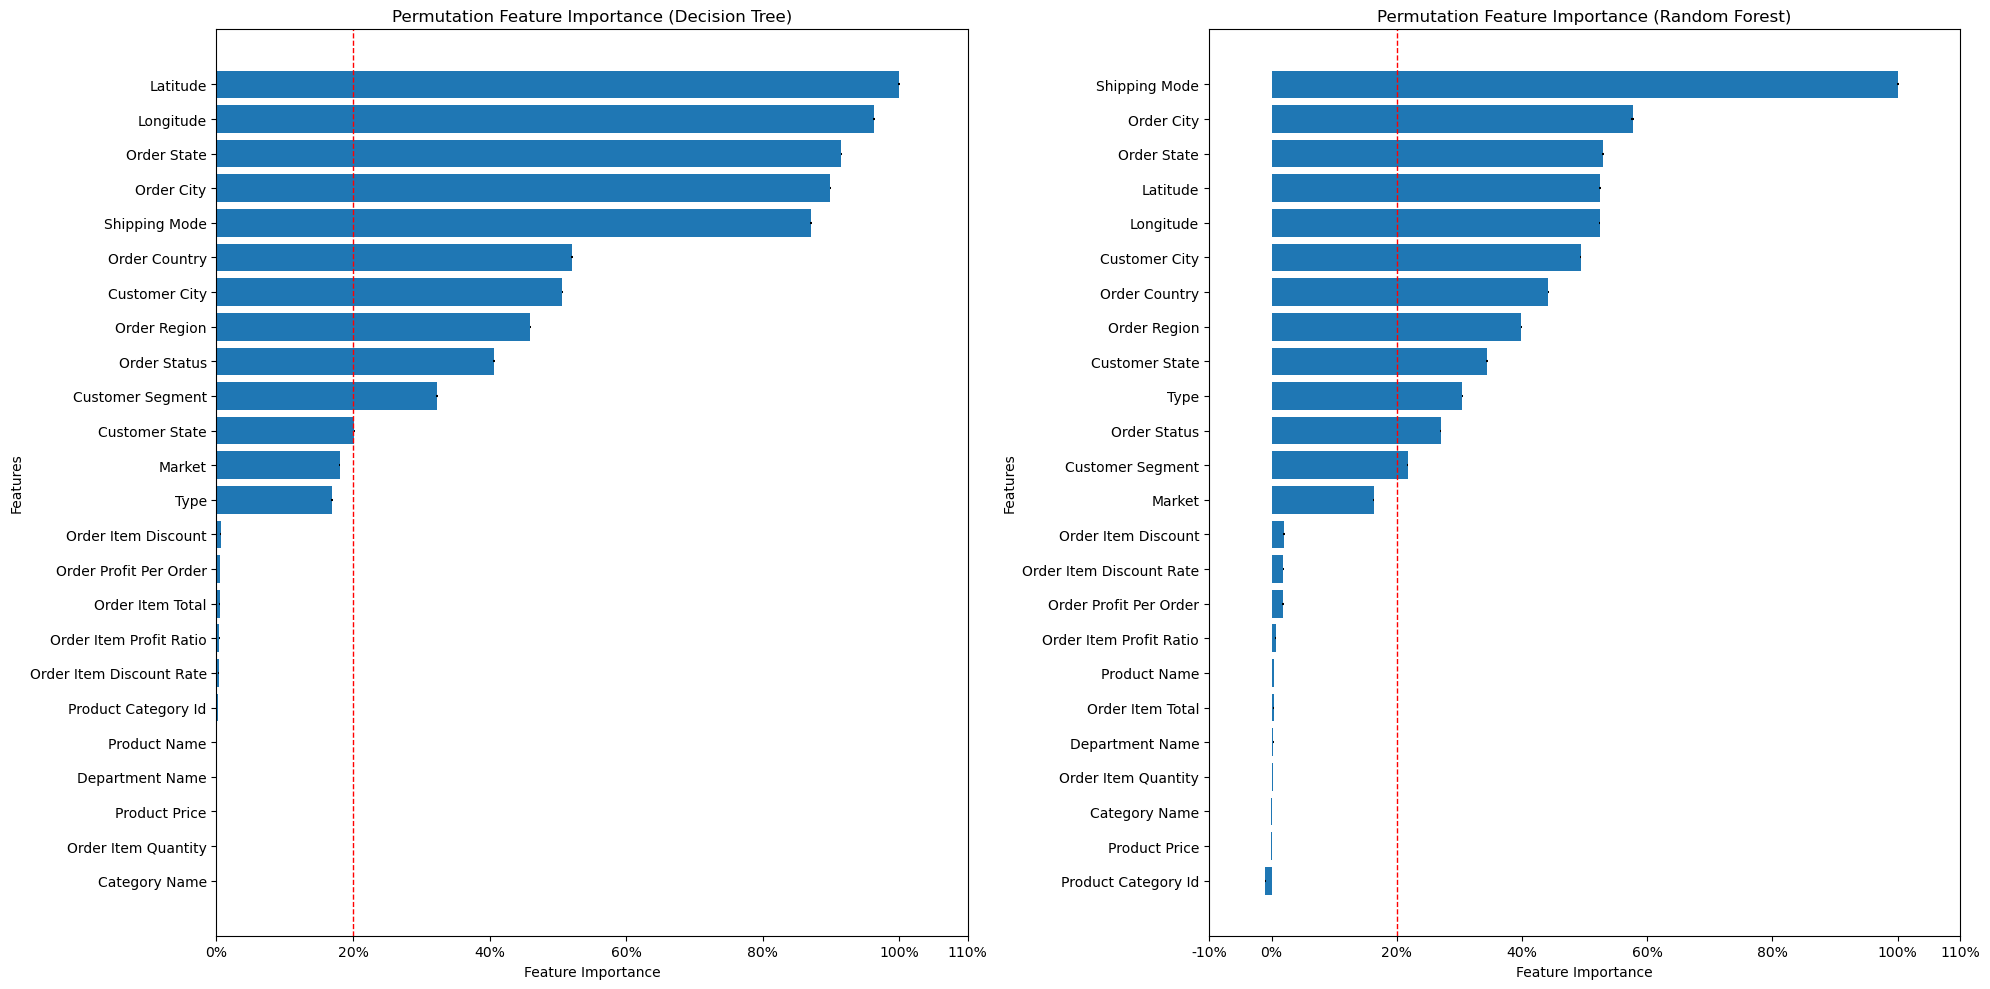

In [67]:
plt.figure(figsize=(20, 10))

# Decision Tree
plt.subplot(1,2,1)
# normalize the feature importance
plt.barh(importance_df_dtc["features"], importance_df_dtc["importance_mean"]/importance_df_dtc["importance_mean"].max(), xerr=importance_df_dtc['importance_std'])
plt.axvline(x=0.2, linestyle="--", linewidth=1, color="red")
plt.xlim(0, 1)
ticks = sorted(list(plt.xticks()[0]) + [1.1])
plt.xticks(ticks, labels=[f"{int(i*100)}%" for i in ticks])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Permutation Feature Importance (Decision Tree)')

# Random Forest
plt.subplot(1,2,2)
# normalize the feature importance
plt.barh(importance_df_rfc["features"], importance_df_rfc["importance_mean"]/importance_df_rfc["importance_mean"].max(), xerr=importance_df_rfc['importance_std'])
plt.axvline(x=0.2, linestyle="--", linewidth=1, color="red")
plt.xlim(0, 1)
ticks = sorted(list(plt.xticks()[0]) + [-0.1, 1.1])
plt.xticks(ticks,  labels=[f"{int(i*100)}%" for i in ticks])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Permutation Feature Importance (Random Forest)')

plt.tight_layout() 
plt.show()

Baed on the permutation importance of both decison tree model and random forest model, we set the threshold as around 0.07.<br>
<br>We can delete the features that is in common for both graph, using threshold of 0.07. The features deleted: [ 'Order Item Quantity', 'Product Category Id', 'Department Name', 'Category Name', 'Order Item Total', 'Product Price', 'Product Name', 'Order Item Profit Ratio', 'Order Item Discount Rate',  'Order Profit Per Order', 'Order Item Discount', 'Type', 'Market', 'Customer Segment' ]<br>
<br>Re-run the model to check the performance

In [67]:
# remove the features based on permutation importance
df_labelEncoding_reduDim = df_labelEncoding.drop(columns=[ 'Order Item Quantity', 'Product Category Id', 'Department Name', 'Category Name', 'Order Item Total', 'Product Price', 'Product Name', 'Order Item Profit Ratio', 'Order Item Discount Rate',  'Order Profit Per Order', 'Order Item Discount', 'Type', 'Market', 'Customer Segment', "Customer State" ])

# re-split the data
x_train_cla_rerun, x_test_cla_rerun, y_train_cla_rerun, y_test_cla_rerun = train_test_split(df_labelEncoding_reduDim, tag, test_size=0.2, shuffle=True, stratify=tag, random_state=2)

dtc = DecisionTreeClassifier(random_state=2)
rfc = RandomForestClassifier(n_estimators=100, random_state=2) 
lgbmc = LGBMClassifier(n_estimators=100, random_state=2)

# parameter grid
model_paras_cla_rerun = [[dtc, {"max_depth": range(2, 40), "min_samples_leaf": range(2, 20)}],
    [rfc, {"max_depth": range(2, 40), "min_samples_leaf": range(2, 20)}],
    [lgbmc, {"max_depth": range(2, 40), "min_child_samples": range(2, 20)}]]

In [68]:
#performance matrix
acc_sc = []
pre_sc = []
rec_sc = []
f1_sc = []
auroc_sc = []

def evaluate_classifier_model_permu():
    temp = 0
    for model, paras in model_paras_cla_rerun:
        grid_search_cv = GridSearchCV(estimator=model, param_grid=paras, cv=3, n_jobs=6, verbose=1)
        grid_search_cv.fit(x_train_cla_rerun, y_train_cla_rerun)
        best_paras = grid_search_cv.best_params_
        best_model = grid_search_cv.best_estimator_
        pred_test = best_model.predict(x_test_cla_rerun)
        pred_test_proba = best_model.predict_proba(x_test_cla_rerun)
        acc_sc.append([model, accuracy_score(y_test_cla_rerun, pred_test)])
        pre_sc.append([model,  precision_score(y_test_cla_rerun, pred_test, average="weighted")]) # "weighted" for imblanced problem
        rec_sc.append([model, recall_score(y_test_cla_rerun, pred_test, average="weighted")])
        f1_sc.append([model, f1_score(y_test_cla_rerun, pred_test, average="weighted")])
        auroc_sc.append([model, roc_auc_score(y_test_cla_rerun, pred_test_proba, average="micro", multi_class="ovr")]) # "micro" for imblanced problem
        cm = confusion_matrix(y_test_cla_rerun, pred_test)
        print(f"""
*************************************************************************
{model.__class__.__name__}:
Best parameters is {best_paras}
Accuracy:{acc_sc[temp][1]: .3f}, Precision:{pre_sc[temp][1]: .3f}, Recall:{rec_sc[temp][1]: .3f}, F1_score:{f1_sc[temp][1]: .3f}
AUROC:{auroc_sc[temp][1]: .3f}
Confusion Matrix: 
{cm}
*************************************************************************""")
        temp += 1

In [69]:
classifier_evaluate_permu = evaluate_classifier_model_permu()

Fitting 3 folds for each of 684 candidates, totalling 2052 fits

*************************************************************************
DecisionTreeClassifier:
Best parameters is {'max_depth': 39, 'min_samples_leaf': 2}
Accuracy: 0.827, Precision: 0.827, Recall: 0.827, F1_score: 0.826
AUROC: 0.944
Confusion Matrix: 
[[  917    99     0     0     0     0     0]
 [  100   831     0     0     0     0     0]
 [    0     0 10240   290   278   247   269]
 [    0     0   346  4686   242   236   243]
 [    0     0   350   380  4491   235   247]
 [    0     0   346   351   357  4350   228]
 [    0     0   324   404   350   331  4336]]
*************************************************************************
Fitting 3 folds for each of 684 candidates, totalling 2052 fits

*************************************************************************
RandomForestClassifier:
Best parameters is {'max_depth': 38, 'min_samples_leaf': 2}
Accuracy: 0.893, Precision: 0.893, Recall: 0.893, F1_score: 0.893


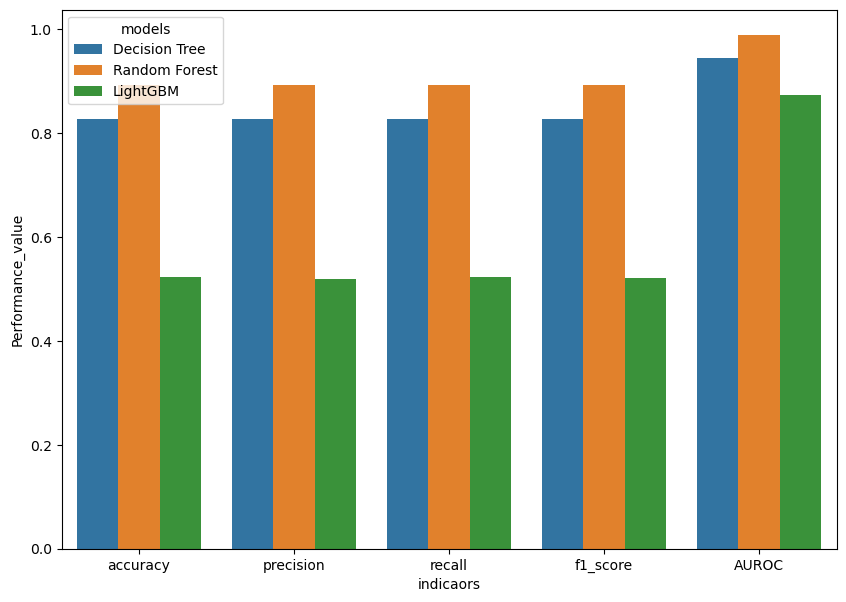

In [70]:
# plot the comparison of performance matrix for different models 
import seaborn as sns
plt.figure(figsize=(10,7))
performance_matrix = {
    "indicaors": ["accuracy"]*3 + ["precision"]*3 + ["recall"]*3 + ["f1_score"]*3 + ["AUROC"]*3,
    "models": ["Decision Tree", "Random Forest", "LightGBM"] * 5,
    "Performance_value": [acc_sc[i][1] for i in range(0,3)] + [pre_sc[i][1] for i in range(0,3)] + [rec_sc[i][1] for i in range(0,3)] + [f1_sc[i][1] for i in range(0,3)] + [auroc_sc[i][1] for i in range(0,3)],
}
performance_df = pd.DataFrame(performance_matrix)
sns.barplot(data=performance_df, y="Performance_value", x="indicaors", hue="models")
plt.show()

From the graph, we can see that the Random Forest Classifier has the best performance with the best parameters found in Grid Search. So we choose the Random Forest Classifier as our final model with best parameters.

In [ ]:
# get the roc from the radom forest classifier

from sklearn.preprocessing import label_binarize

n_tag_class = len(np.unique(tag))
tag_bin = label_binarize(y=tag, classes=np.arange(n_tag_class)) # one-hot the target column
x_train_cla_roc, x_test_cla_roc, y_train_cla_roc, y_test_cla_roc = train_test_split(df_labelEncoding_reduDim, tag_bin, test_size=0.2, shuffle=True, stratify=tag, random_state=2)

best_model_roc = RandomForestClassifier(n_estimators=100, max_depth=39, min_samples_leaf=2, random_state=2) # with best parameters in grid search
best_model_roc.fit(x_train_cla_roc, y_train_cla_roc)
y_proba_roc = best_model_roc.predict_proba(x_test_cla_roc)
y_proba_roc = np.column_stack([y_proba_roc[i][:,1] for i in range(n_tag_class)]) # extract the positive class

# roc for different taget classes
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_tag_class):
    fpr[i], tpr[i], _ = roc_curve(y_test_cla_roc[:,i], y_proba_roc[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# final micro-average roc
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_cla_roc.ravel(), y_proba_roc.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


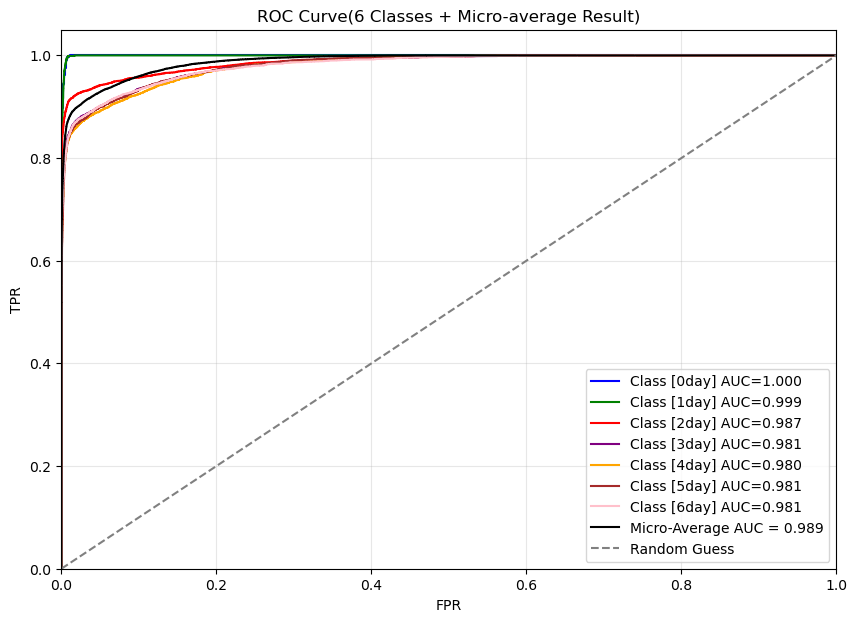

In [72]:
# plot the roc curve for different taget classes and final micro-average result

plt.figure(figsize=(10, 7), dpi=100)
colors = ["blue", "green", "red", "purple", "orange", "brown", "pink"]

for i in range(n_tag_class):
    plt.plot(fpr[i], tpr[i], color=colors[i], label=f"Class [{i}day] AUC={roc_auc[i]:.3f}")
plt.plot(fpr["micro"], tpr["micro"], color="black", label=f"Micro-Average AUC = {roc_auc["micro"]:.3f}")
# Random guess line
plt.plot([0, 1], [0, 1], color='gray', label="Random Guess", linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve(6 Classes + Micro-average Result)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

The AUC for each class is balanced and the final micro-average AUC is good. The Random Forest Classifier is a good final solution.

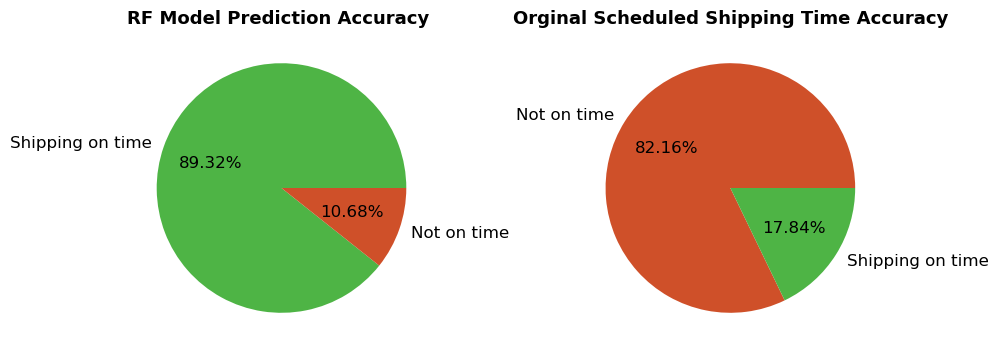

In [95]:
# pie chart to compare the prediction accuracy with the orginal scheduled shipping time

fig, axes_accuracy_compare = plt.subplots(1, 2, figsize=(10, 7))
df_delivery = df.copy()
df_delivery.loc[df["Delivery Status"] != "Shipping on time", "Delivery Status"] = "Not on time"
delivery_status_count = df_delivery.loc[:, "Delivery Status"].value_counts()
axes_accuracy_compare[1].pie(delivery_status_count, labels=delivery_status_count.index, autopct="%.2f%%", colors= ["#CF5029", "#4EB445"], textprops = {"fontsize": 12})
axes_accuracy_compare[0].pie([float(acc_sc[1][1]), float(1-acc_sc[1][1])], labels=["Shipping on time", "Not on time"], autopct="%.2f%%", colors= ["#4EB445", "#CF5029"], textprops = {"fontsize": 12})
axes_accuracy_compare[1].set_title("Orginal Scheduled Shipping Time Accuracy", fontweight='bold', fontsize = 13)
axes_accuracy_compare[0].set_title("RF Model Prediction Accuracy ", fontweight='bold', fontsize = 13)
plt.tight_layout()
plt.show()


We can see that the On Time rate can be increased from 17.84% to 89.32% by using the chosen predition model.